# 02 - VQE on a Real Molecule (H₂)

What this notebook answers:

- How do I turn a real molecular Hamiltonian (PennyLane `qchem`) into a PADO-Pauli observable?
- How do I run a VQE ground-state optimization through the compiled surrogate with plain
  `torch.optim`?
- Does it actually reach the exact (FCI) energy? (Yes, within the notebook's 1e-8 check for H₂/STO-3G.)
- How do I scan a bond-dissociation curve by recompiling per geometry?

## Notebook Guide / 노트북 가이드

- **EN** Chemistry input comes from PennyLane qchem; everything after that is PADO-Pauli + torch.
- **KO** 화학 입력은 PennyLane qchem에서 오고, 그 이후는 전부 PADO-Pauli + torch입니다.
- **EN** Section flow: Hamiltonian → convert to PauliSum → ansatz → train → FCI check → dissociation curve.
- **KO** 섹션 순서: 해밀토니안 → PauliSum 변환 → ansatz → 학습 → FCI 검증 → 해리 곡선.
- **EN** Expected outcome: VQE energy equal to FCI at every bond length (single-parameter ansatz).
- **KO** 기대 결과: 모든 결합 길이에서 VQE 에너지가 FCI와 일치합니다 (파라미터 1개 ansatz).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import torch

import padopauli
from padopauli import Circuit, PauliSum

use_cuda = torch.cuda.is_available()
nb_preset = "gpu" if use_cuda else "cpu"
print(f"padopauli {padopauli.__version__}")
print(f"torch {torch.__version__} | cuda available: {use_cuda} | preset: {nb_preset}")

import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# plot style
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
plt.rcParams.update({
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
import os
os.makedirs("figures", exist_ok=True)


padopauli 2.0.0
torch 2.11.0+rocm7.2 | cuda available: True | preset: gpu


## 1) The molecular Hamiltonian

PennyLane's built-in `qchem` module computes the second-quantized electronic Hamiltonian of
H₂ in the minimal STO-3G basis and maps it to qubits (Jordan-Wigner): **4 qubits, 15 Pauli
terms**. PADO-Pauli then treats it as just another `PauliSum` observable.

In [2]:
ANGSTROM_TO_BOHR = 1.0 / 0.529177210903

def h2_hamiltonian(bond_angstrom):
    """H2 electronic Hamiltonian (STO-3G, Jordan-Wigner) at the given bond length."""
    coords = np.array([0.0, 0.0, 0.0, 0.0, 0.0, bond_angstrom * ANGSTROM_TO_BOHR])
    H, n_qubits = qml.qchem.molecular_hamiltonian(["H", "H"], coords, basis="sto-3g")
    return H, n_qubits

H, n_qubits = h2_hamiltonian(0.7414)     # experimental equilibrium bond length
coeffs, ops = H.terms()
print(f"n_qubits = {n_qubits}, Pauli terms = {len(coeffs)}")
wire_map = {i: i for i in range(n_qubits)}
for c, op in zip(coeffs, ops):
    print(f"  {float(c):+.8f}  {qml.pauli.pauli_word_to_string(op, wire_map=wire_map)}")

n_qubits = 4, Pauli terms = 15
  -0.09886398  IIII
  +0.17119775  ZIII
  +0.17119775  IZII
  +0.16862219  ZZII
  -0.22278593  IIZI
  +0.12054482  ZIZI
  +0.16586702  IZZI
  +0.04532220  YXXY
  -0.04532220  YYXX
  -0.04532220  XXYY
  +0.04532220  XYYX
  -0.22278593  IIIZ
  +0.16586702  ZIIZ
  +0.12054482  IZIZ
  +0.17434844  IIZZ


## 2) Converting to a PADO-Pauli observable

Each Pauli word maps to one `add_from_str` call. The all-identity term is a constant energy
offset — we keep it classically and add it back after the expectation value.

In [3]:
def to_pauli_sum(H, n_qubits):
    """PennyLane Hamiltonian -> (PauliSum, identity offset)."""
    obs = PauliSum(n_qubits)
    offset = 0.0
    wire_map = {i: i for i in range(n_qubits)}
    for c, op in zip(*H.terms()):
        word = qml.pauli.pauli_word_to_string(op, wire_map=wire_map)
        qubits = [q for q, ch in enumerate(word) if ch != "I"]
        if not qubits:
            offset += float(c)
            continue
        obs.add_from_str("".join(word[q] for q in qubits), float(c), qubits=qubits)
    return obs, offset

obs, e_offset = to_pauli_sum(H, n_qubits)
print(f"{len(obs.terms)} non-identity terms, identity offset = {e_offset:+.8f} Ha")

14 non-identity terms, identity offset = -0.09886398 Ha


## 3) The ansatz

For H₂/STO-3G the exact ground state lives in the 2-determinant subspace
{|1100⟩, |0011⟩}, so a **single-parameter** ansatz is already exact:

1. Prepare the Hartree-Fock state |1100⟩ with two Clifford X gates: `qc.x(0)`, `qc.x(1)`.
2. Apply one **double-excitation rotation** `qc.rot("XXXY", [0, 1, 2, 3], param_idx=0)`
   = exp(-i θ/2 · X₀X₁X₂Y₃), which rotates |1100⟩ into the |0011⟩ direction.

This is the UCCSD ansatz reduced to its only non-trivial generator. A `PauliSum`
observable goes into `qc.compile(observables=[obs], ...)` as-is.

In [4]:
def h2_ansatz():
    qc = Circuit(4)
    qc.x(0); qc.x(1)                              # Hartree-Fock |1100>
    qc.rot("XXXY", [0, 1, 2, 3], param_idx=0)     # double excitation
    return qc

qc = h2_ansatz()
program = qc.compile(observables=[obs], preset=nb_preset, dtype="float64")
qc.draw()

theta0 = torch.zeros(1, dtype=torch.float64)
print(f"HF energy (theta=0): {float(program.expvals(theta0)[0]) + e_offset:+.8f} Ha")

propagate:   0%|          | 0/3 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 18


zero-filter:   0%|          | 0/3 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 12 (66.666667% of peak)
q0:─X─RXθ₀─<H>
       │
q1:─X──RX──<H>
       │
q2:────RX──<H>
       │
q3:────RY──<H>

compiled: preset=gpu, max_weight=default, zero_filter=True, n_params=1, n_embedding=0


HF energy (theta=0): -1.11668439 Ha


## 4) Training

A plain torch training loop: the compiled program is differentiable, so `Adam` on the energy
is all it takes.

In [5]:
def run_vqe(program, e_offset, steps=300, lr=0.05):
    theta = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([theta], lr=lr)
    history = []
    for _ in range(steps):
        opt.zero_grad(set_to_none=True)
        energy = program.expvals(theta)[0] + e_offset
        energy.backward()
        opt.step()
        history.append(float(energy))
    return theta.detach(), history

theta_star, history = run_vqe(program, e_offset)
e_vqe = history[-1]
print(f"VQE energy  : {e_vqe:+.10f} Ha   (theta* = {float(theta_star):+.6f})")

VQE energy  : -1.1372701749 Ha   (theta* = -0.226136)


## 5) Exact (FCI) check

The Hamiltonian is a 16×16 matrix — diagonalize it and compare against chemical accuracy,
1.6 mHa; the notebook checks that the VQE energy agrees with FCI to 1e-8.

FCI energy  : -1.1372701749 Ha
VQE - FCI   : -2.220e-16 Ha   (chemical accuracy = 1.6e-3 Ha)


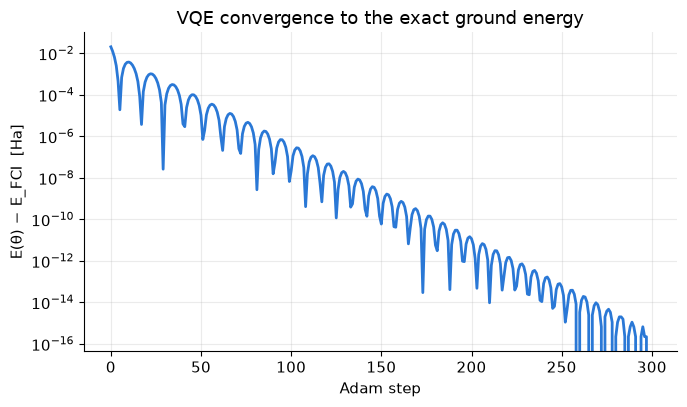

In [6]:
Hmat = qml.matrix(H, wire_order=range(n_qubits))
e_fci = float(np.linalg.eigvalsh(Hmat)[0].real)
print(f"FCI energy  : {e_fci:+.10f} Ha")
print(f"VQE - FCI   : {e_vqe - e_fci:+.3e} Ha   (chemical accuracy = 1.6e-3 Ha)")
assert abs(e_vqe - e_fci) < 1e-8

fig, ax = plt.subplots()
ax.plot(np.array(history) - e_fci, color=PALETTE[0], lw=2)
ax.set_yscale("log")
ax.set_xlabel("Adam step")
ax.set_ylabel("E(θ) − E_FCI  [Ha]")
ax.set_title("VQE convergence to the exact ground energy")
plt.tight_layout()
plt.savefig("figures/fig_vqe_h2_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 6) Bond-dissociation curve

The observable changes with geometry, so each bond length is a fresh compile — which is
exactly the "compile once (per Hamiltonian), evaluate many" model. Each point below is a
full compile + VQE optimization (`verbosity=0` silences the per-compile progress lines).

In [7]:
bond_lengths = np.linspace(0.4, 2.4, 11)
e_vqe_curve, e_fci_curve, e_hf_curve = [], [], []

for R in bond_lengths:
    H_R, nq = h2_hamiltonian(float(R))
    obs_R, off_R = to_pauli_sum(H_R, nq)
    prog_R = h2_ansatz().compile(observables=[obs_R], preset=nb_preset,
                                 dtype="float64", verbosity=0)
    e_hf_curve.append(float(prog_R.expvals(torch.zeros(1, dtype=torch.float64))[0]) + off_R)
    _, hist = run_vqe(prog_R, off_R, steps=250)
    e_vqe_curve.append(hist[-1])
    e_fci_curve.append(float(np.linalg.eigvalsh(qml.matrix(H_R, wire_order=range(nq)))[0].real))
    print(f"R = {R:4.2f} A : VQE {e_vqe_curve[-1]:+.8f}  FCI {e_fci_curve[-1]:+.8f}"
          f"  |dE| = {abs(e_vqe_curve[-1] - e_fci_curve[-1]):.1e}")

R = 0.40 A : VQE -0.91414970  FCI -0.91414970  |dE| = 3.1e-14


R = 0.60 A : VQE -1.11628601  FCI -1.11628601  |dE| = 4.4e-15


R = 0.80 A : VQE -1.13414767  FCI -1.13414767  |dE| = 2.6e-14


R = 1.00 A : VQE -1.10115033  FCI -1.10115033  |dE| = 4.4e-14


R = 1.20 A : VQE -1.05674075  FCI -1.05674075  |dE| = 8.4e-14


...

R = 1.60 A : VQE -0.98347273  FCI -0.98347273  |dE| = 3.9e-13


R = 1.80 A : VQE -0.96181695  FCI -0.96181695  |dE| = 5.1e-13


R = 2.00 A : VQE -0.94864111  FCI -0.94864111  |dE| = 9.3e-13


R = 2.20 A : VQE -0.94122404  FCI -0.94122404  |dE| = 7.6e-14


R = 2.40 A : VQE -0.93725495  FCI -0.93725495  |dE| = 1.7e-12


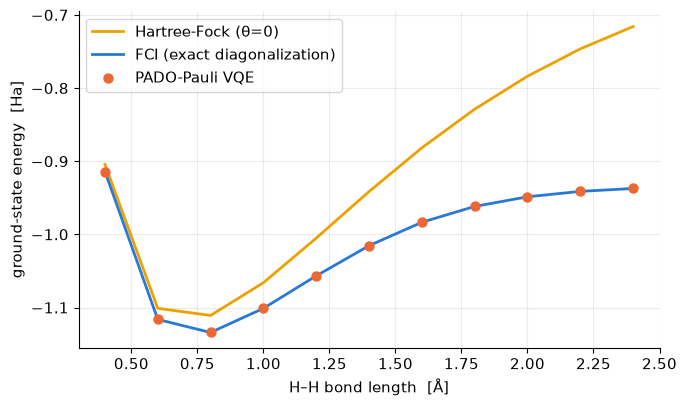

max |VQE - FCI| over the curve: 1.74e-12 Ha


In [8]:
fig, ax = plt.subplots()
ax.plot(bond_lengths, e_hf_curve, color=PALETTE[3], lw=2, label="Hartree-Fock (θ=0)")
ax.plot(bond_lengths, e_fci_curve, color=PALETTE[0], lw=2, label="FCI (exact diagonalization)")
ax.scatter(bond_lengths, e_vqe_curve, color=PALETTE[1], zorder=3, s=42, label="PADO-Pauli VQE")
ax.set_xlabel("H–H bond length  [Å]")
ax.set_ylabel("ground-state energy  [Ha]")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_vqe_h2_dissociation.png", dpi=150, bbox_inches="tight")
plt.show()

max_err = max(abs(a - b) for a, b in zip(e_vqe_curve, e_fci_curve))
print(f"max |VQE - FCI| over the curve: {max_err:.2e} Ha")

## Notes on scaling up

- Larger molecules follow the same recipe: `qml.qchem.molecular_hamiltonian` → `to_pauli_sum`
  → an ansatz built with `Circuit.rot` (e.g. all UCCSD excitation generators, one
  `param_idx` each) → `qc.compile` → torch training.
- For bigger ansätze, use `preset="gpu"` and the truncation knob from `01_kicked_ising_127q.ipynb`
  (`qc.compile(..., max_weight=w)`), then validate against `expvals_reference` while the
  system is still ≤ 20 qubits.
- Parameter batches (`tutorial/07_parameter_batch_evaluation.ipynb`) give you multi-start VQE: initialize
  `theta` as `(n_starts, n_params)` and optimize the mean energy.